In [1]:
from src.datasets import load_tinystories_dataloaders
from src.tokenizers import load_tinystories_tokenizer
from src.training import train
from nanoGPT.model import GPT, GPTConfig

c:\Users\will\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
tokenizer = load_tinystories_tokenizer()

In [3]:
train_dataloader, val_dataloader, test_dataloader = load_tinystories_dataloaders(tokenizer, train_size=128, val_size=128, test_size=128, sw=True)

Saving sliding dataset to c:\Users\will\Desktop\llm-research\src\datasets\../../data/datasets\sw\tinystories_sw_(tokenizer=tinystories_tokenizer_10k)_(cs=512)


TypeError: Values in `DatasetDict` should be of type `Dataset` but got type '<class 'datasets.iterable_dataset.IterableDataset'>'

In [ ]:
config = GPTConfig(
  block_size=512,
  vocab_size=len(tokenizer),
  n_layer=1,
  n_head=12,
  n_embd=768,
  dropout=0.1,
  ln_setting='pre',
  input_vectors=['w', 'w', 'w']
)

model = GPT(config)
model.name = 'nanoGPT_1L_12H_512E'

number of parameters: 10.50M


Training model nanoGPT_1L_12H_512E [Using device: cpu]
Epoch 1 | Batch 4 / 4 | Train Loss: 4.1663 | Most Recent Val Loss: 4.1032 | Batch Time Remaining: 00:00:00Epoch 1 / 3 | Train Loss: 4.4823 | Val Loss: 4.1032 | Time Remaining: 00:03:06


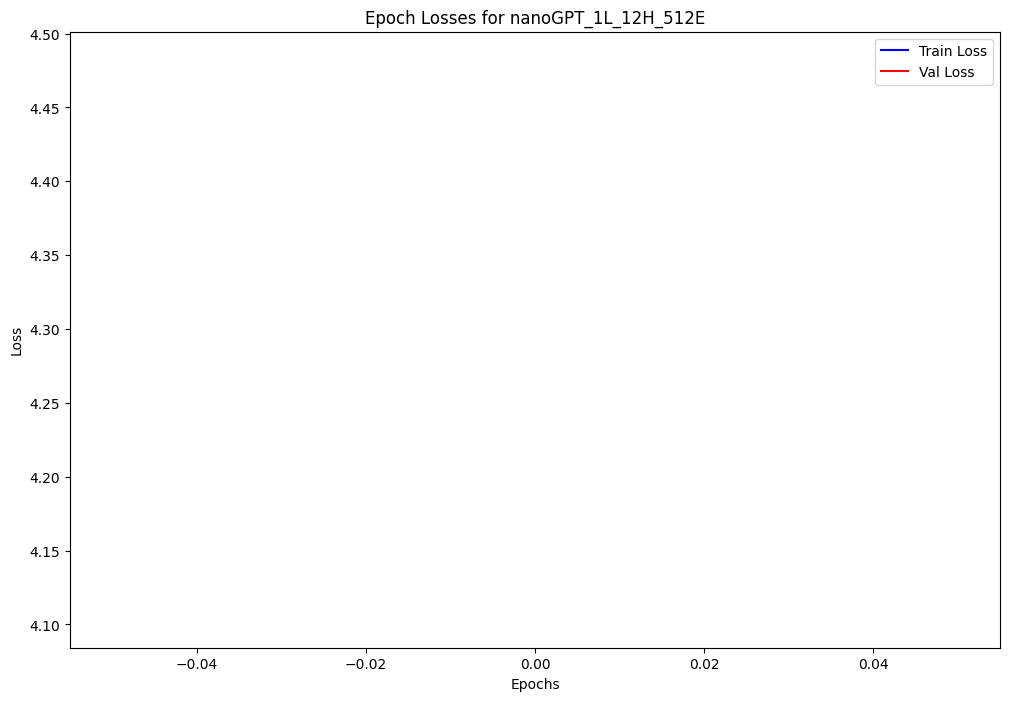

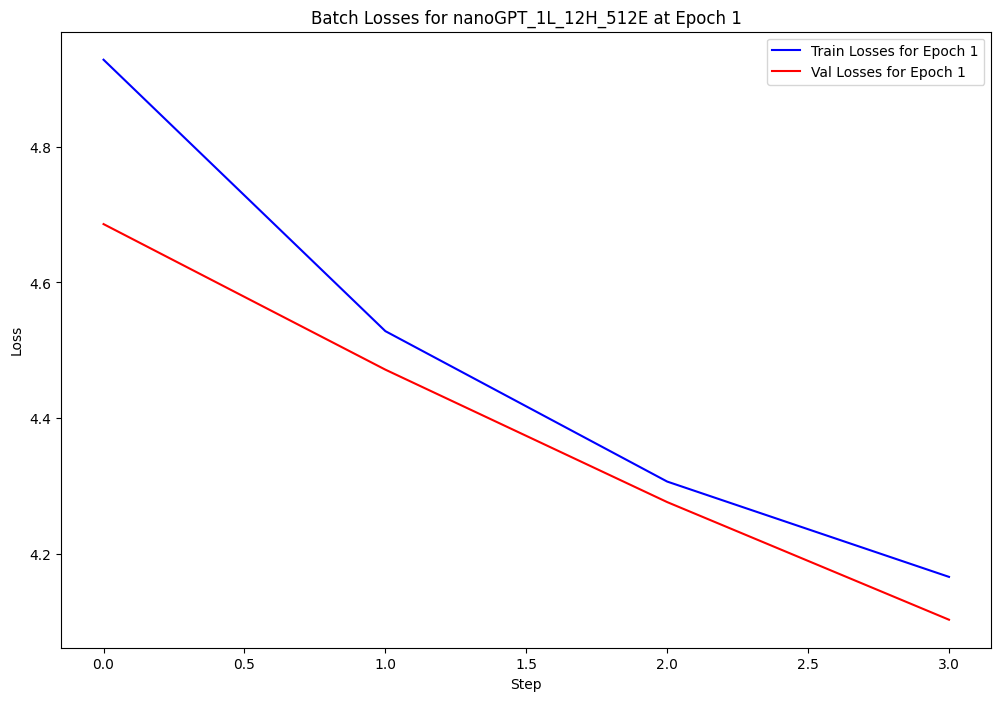

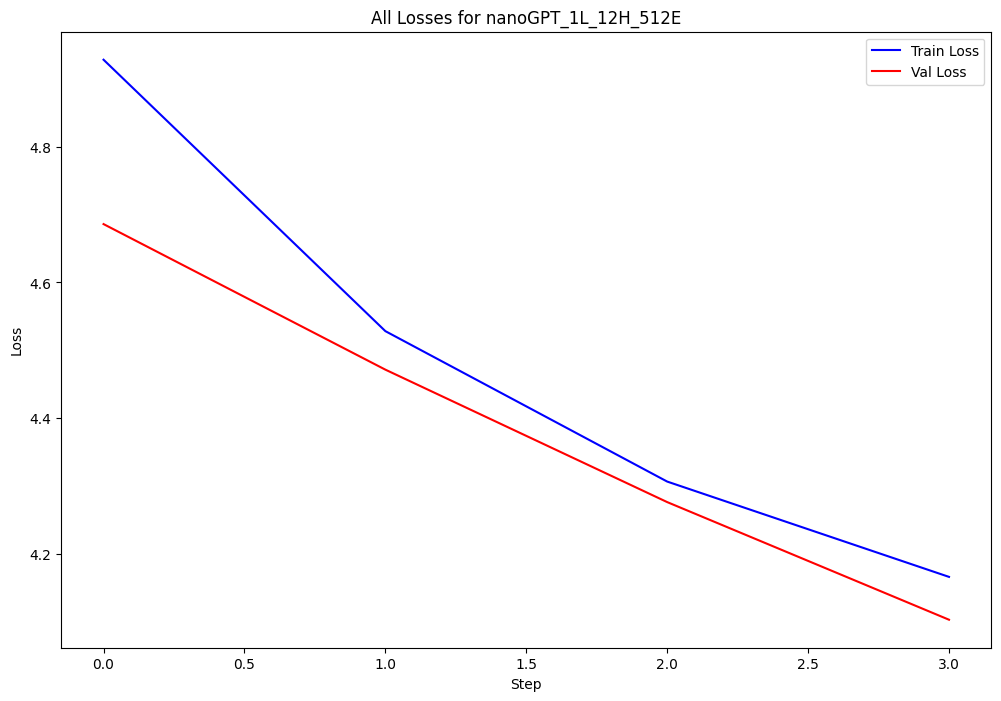

Epoch 2 | Batch 4 / 4 | Train Loss: 3.6424 | Most Recent Val Loss: 3.6380 | Batch Time Remaining: 00:00:00Epoch 2 / 3 | Train Loss: 3.7693 | Val Loss: 3.6380 | Time Remaining: 00:01:34


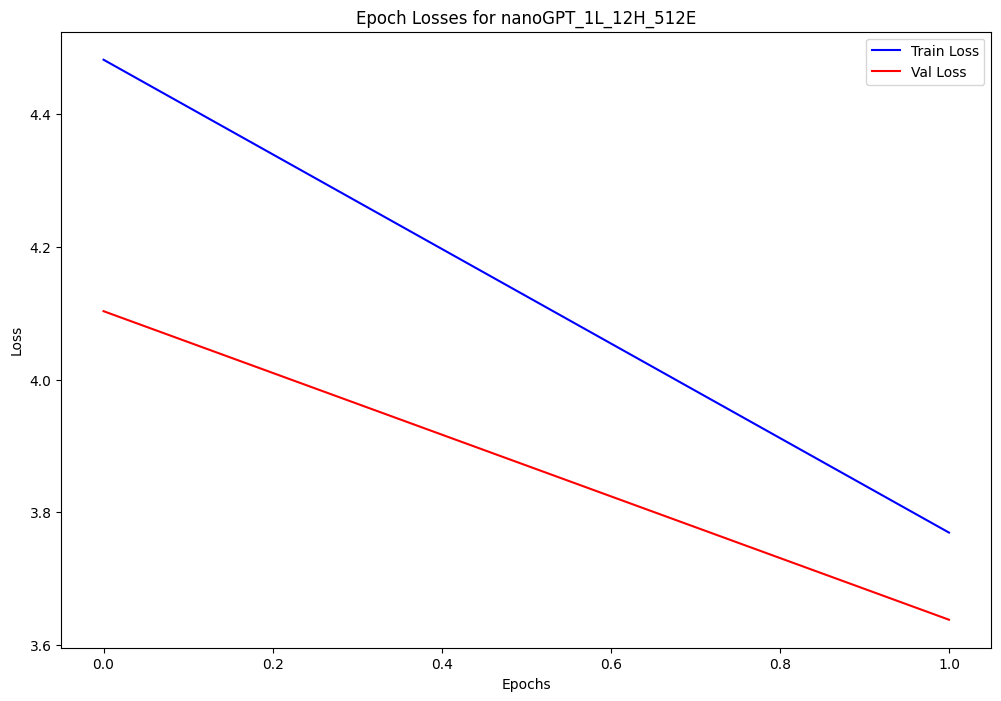

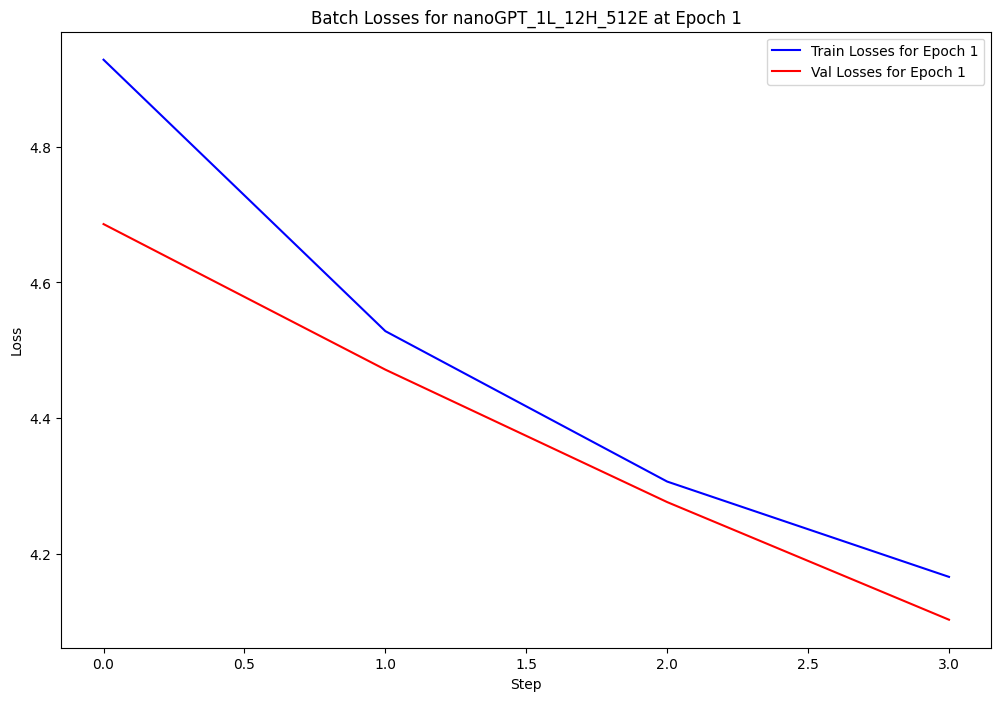

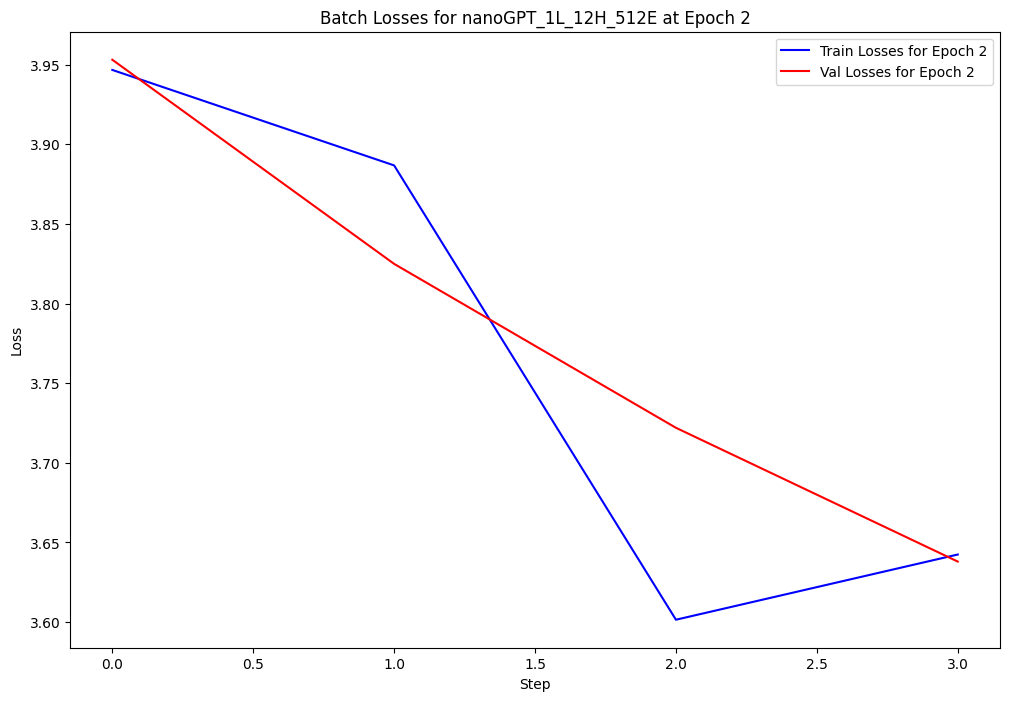

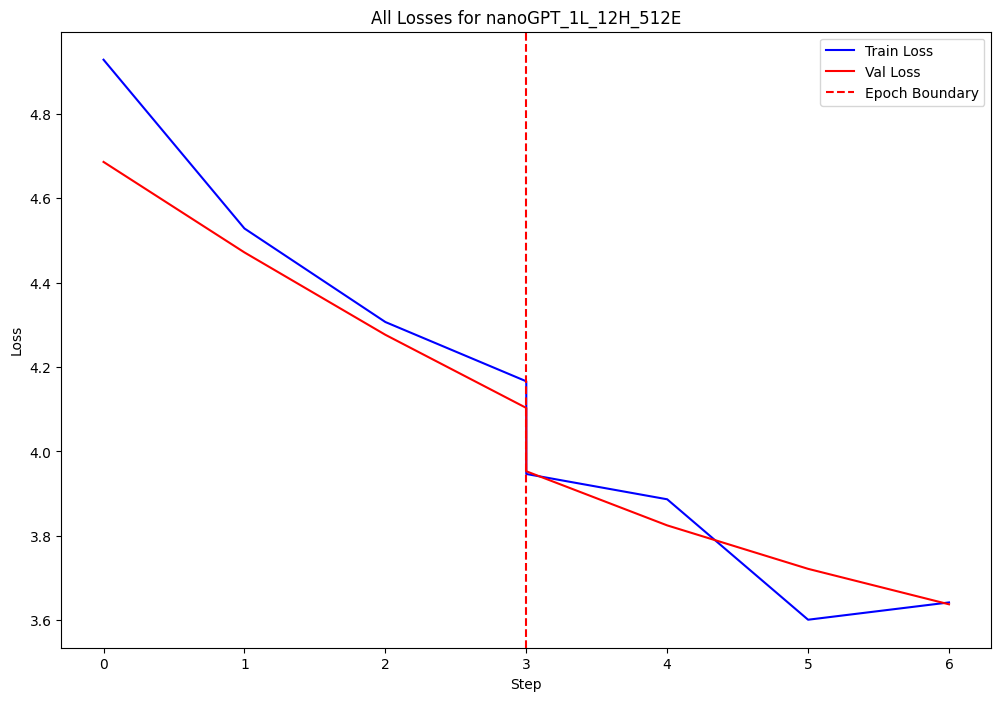

Epoch 3 | Batch 4 / 4 | Train Loss: 3.0574 | Most Recent Val Loss: 3.4373 | Batch Time Remaining: 00:00:00Epoch 3 / 3 | Train Loss: 3.4068 | Val Loss: 3.4373 | Time Remaining: 00:00:00


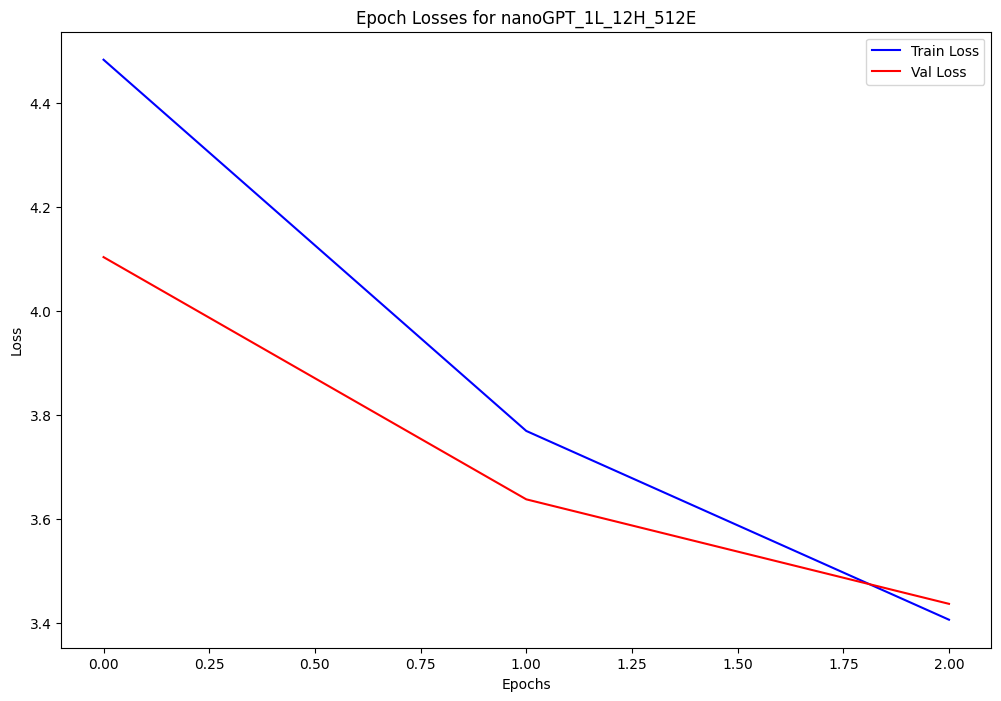

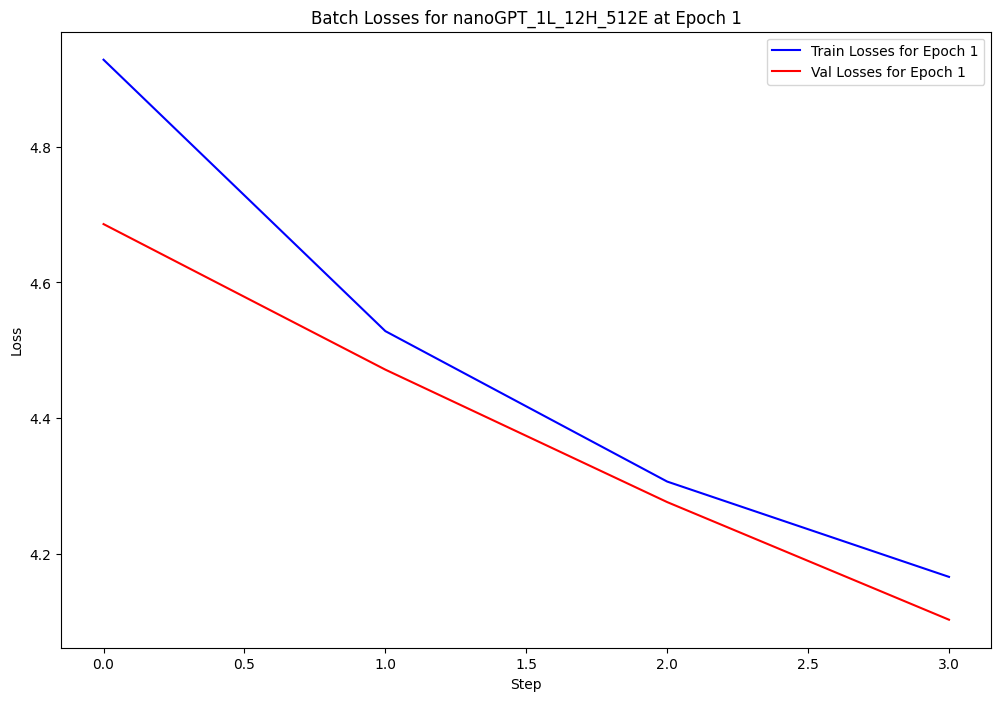

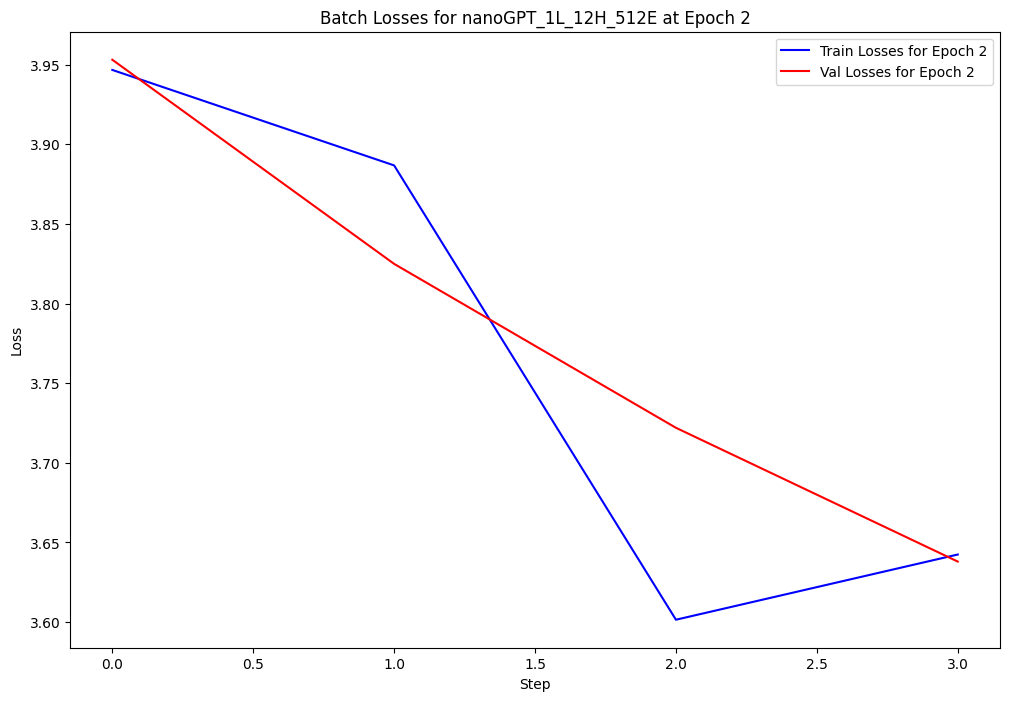

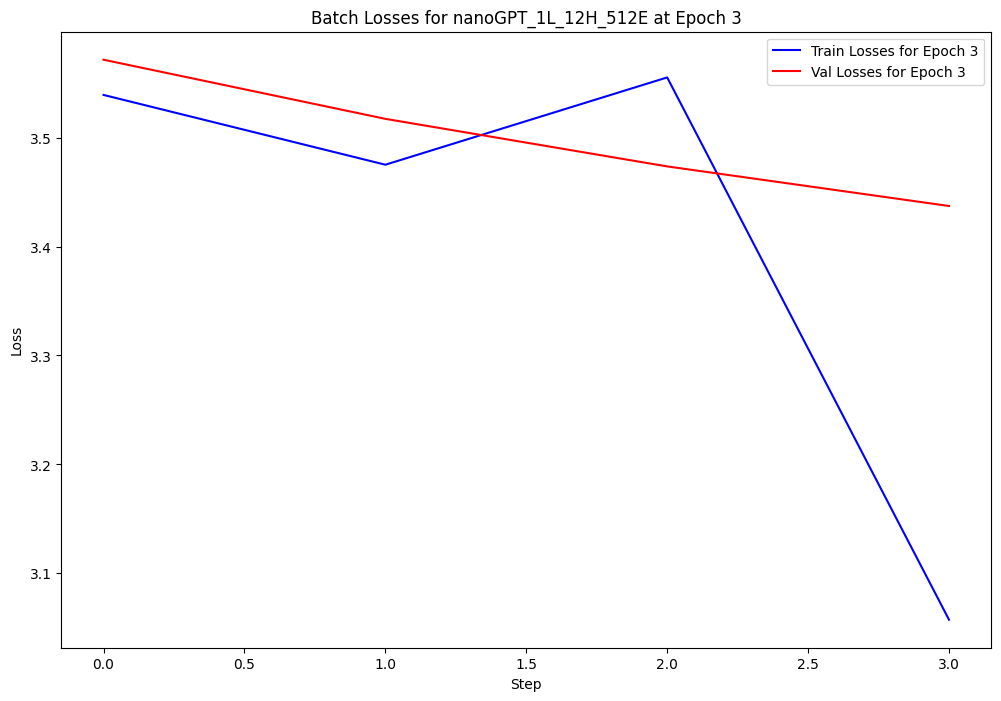

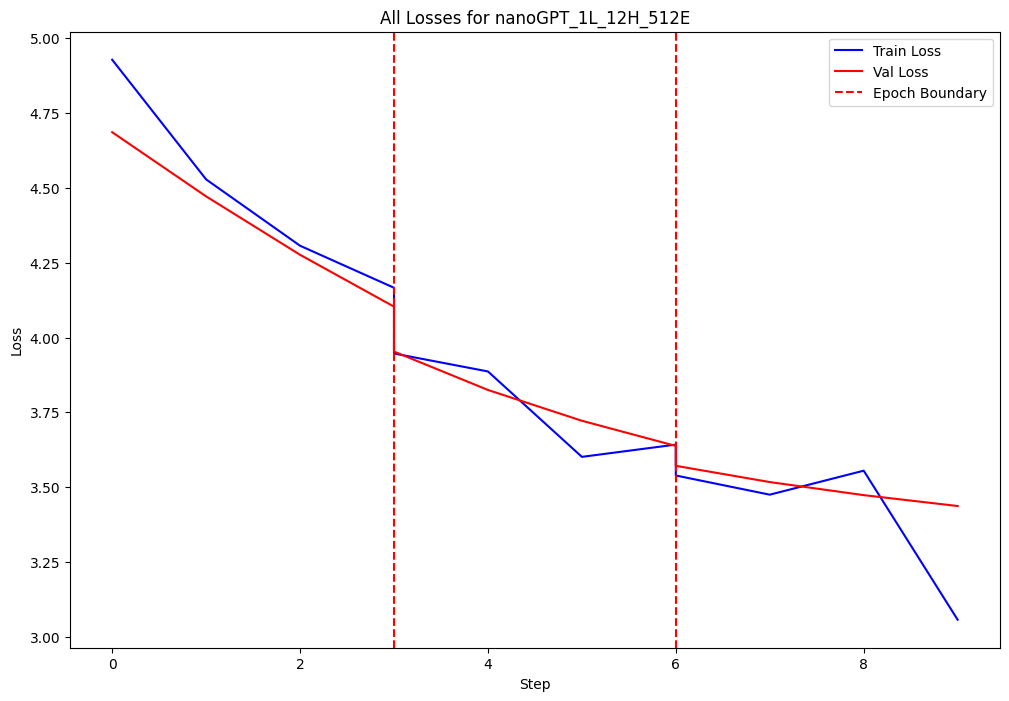

Training complete | Train Loss: 3.4068 | Val Loss: 3.4373


In [ ]:
train_results, eval_results = train(model, train_dataloader, val_dataloader, num_epochs=3, device='cpu')